In [41]:
# DataFrame
import pandas as pd

# Matplot
import matplotlib.pyplot as plt
%matplotlib inline

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

# TensorFlow Keras (à la place de keras direct)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Dropout, Embedding, Flatten, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras import utils
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# nltk
import nltk
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

# Word2vec
import gensim

# Utility
import re
import numpy as np
import os
from collections import Counter
import logging
import time
import pickle
import itertools

# Set log
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [29]:
# Download stopwords like "le, the, a, an, etc." which are not useful for sentiment analysis and will be removed from the text.
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\othma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Settings

In [42]:
# DATASET
DATASET_COLUMNS = ["target", "ids", "date", "flag", "user", "text"]
DATASET_ENCODING = "ISO-8859-1"
TRAIN_SIZE = 0.8

# TEXT CLENAING
TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"

# WORD2VEC 
W2V_SIZE = 300
W2V_WINDOW = 7
W2V_EPOCH = 32
W2V_MIN_COUNT = 10

# KERAS
SEQUENCE_LENGTH = 300
EPOCHS = 8
BATCH_SIZE = 1024

# SENTIMENT
POSITIVE = "POSITIVE"
NEGATIVE = "NEGATIVE"
NEUTRAL = "NEUTRAL"
SENTIMENT_THRESHOLDS = (0.4, 0.7)

# EXPORT
KERAS_MODEL = "model.h5"
WORD2VEC_MODEL = "model.w2v"
TOKENIZER_MODEL = "tokenizer.pkl"
ENCODER_MODEL = "encoder.pkl"

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\othma\AppData\Local\Temp\ipykernel_25176\4085933549.py:7: SyntaxWarning: invalid escape sequence '\S'
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"


### Read Dataset

### Dataset details
* **target**: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)
* **ids**: The id of the tweet ( 2087)
* **date**: the date of the tweet (Sat May 16 23:58:44 UTC 2009)
* **flag**: The query (lyx). If there is no query, then this value is NO_QUERY.
* **user**: the user that tweeted (robotickilldozr)
* **text**: the text of the tweet (Lyx is cool)

In [43]:
dataset_filename = os.listdir("../models/input")[0]
dataset_path = os.path.join("../models","input",dataset_filename)
print("Open file:", dataset_path)
df = pd.read_csv(dataset_path, encoding =DATASET_ENCODING , names=DATASET_COLUMNS)

Open file: ../models\input\trainingdata.csv


In [44]:
print("Dataset size:", len(df))

Dataset size: 1600000


In [45]:
df.head(5)

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### Map target label to String
* **0** -> **NEGATIVE**
* **2** -> **NEUTRAL**
* **4** -> **POSITIVE**

In [46]:
decode_map = {0: "NEGATIVE", 2: "NEUTRAL", 4: "POSITIVE"}
# Function to decode sentiment labels
def decode_sentiment(label):
    return decode_map[int(label)]

In [47]:
%%time
# Decode sentiment labels in the 'target' column
df.target = df.target.apply(lambda x: decode_sentiment(x))

CPU times: total: 93.8 ms
Wall time: 406 ms


In [36]:
# Display the first 5 rows of the DataFrame to verify the changes
df.head(5)

,target,ids,date,flag,user,text
0,NEGATIVE,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,NEGATIVE,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,NEGATIVE,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,NEGATIVE,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,NEGATIVE,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


Text(0.5, 1.0, 'Dataset labels distribuition')

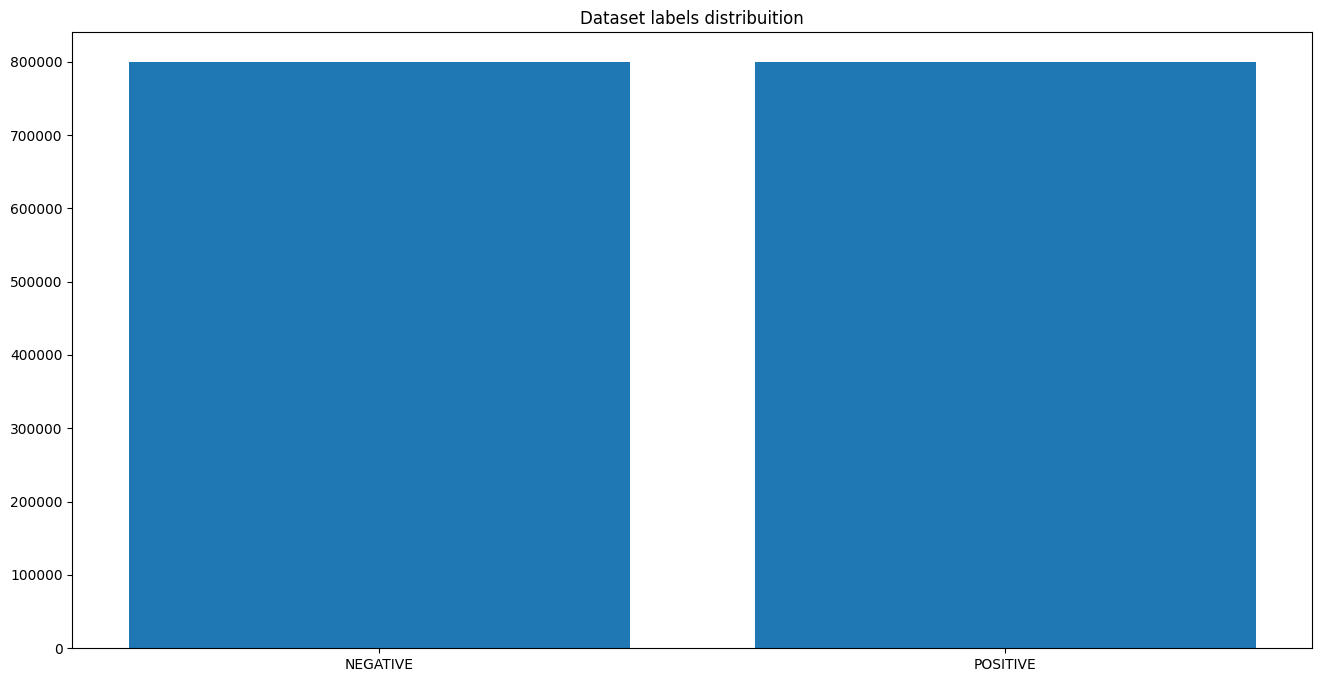

In [37]:
target_cnt = Counter(df.target)

plt.figure(figsize=(16,8))
plt.bar(target_cnt.keys(), target_cnt.values())
plt.title("Dataset labels distribuition")

### Pre-Process dataset

In [48]:
stop_words = stopwords.words("english")
stemmer = SnowballStemmer("english")

In [49]:
# Function to preprocess text (remove links, users, special characters, stop words and apply stemming)
def preprocess(text, stem=False):
    # Remove link,user and special characters
    text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
    tokens = []
    for token in text.split():
        if token not in stop_words:
            if stem:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [50]:
%%time
# Preprocess the text in the 'text' column of the DataFrame
df.text = df.text.apply(lambda x: preprocess(x))

CPU times: total: 24.2 s
Wall time: 57.3 s


In [51]:
# Display the first 5 rows of the DataFrame to verify the changes
df.head(5)

,target,ids,date,flag,user,text
0,NEGATIVE,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,awww bummer shoulda got david carr third day
1,NEGATIVE,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset update facebook texting might cry result...
2,NEGATIVE,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,dived many times ball managed save 50 rest go ...
3,NEGATIVE,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,whole body feels itchy like fire
4,NEGATIVE,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,behaving mad see


### Split train and test

In [52]:
# Split the dataset into training and testing sets
df_train, df_test = train_test_split(df, test_size=1-TRAIN_SIZE, random_state=42)
print("TRAIN size:", len(df_train))
print("TEST size:", len(df_test))

TRAIN size: 1280000
TEST size: 320000


### Word2Vec 

In [53]:
%%time
# Create a list of words from the 'text' column of the training DataFrame for each text
documents = [_text.split() for _text in df_train.text] 

CPU times: total: 1.12 s
Wall time: 3.71 s


In [54]:
# Train a Word2Vec model using the list of documents
w2v_model = gensim.models.word2vec.Word2Vec(vector_size=W2V_SIZE, 
                                            window=W2V_WINDOW, 
                                            min_count=W2V_MIN_COUNT, 
                                            workers=8)

2026-05-16 17:56:04,715 : INFO : Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=300, alpha=0.025>', 'datetime': '2026-05-16T17:56:04.715200', 'gensim': '4.4.0', 'python': '3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.22631-SP0', 'event': 'created'}


In [55]:
# Build the vocabulary for the Word2Vec model using the list of documents
w2v_model.build_vocab(documents)

2026-05-16 17:56:10,412 : INFO : collecting all words and their counts
2026-05-16 17:56:10,413 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-05-16 17:56:10,428 : INFO : PROGRESS: at sentence #10000, processed 72565 words, keeping 14005 word types
2026-05-16 17:56:10,447 : INFO : PROGRESS: at sentence #20000, processed 144393 words, keeping 21587 word types
2026-05-16 17:56:10,469 : INFO : PROGRESS: at sentence #30000, processed 215826 words, keeping 27541 word types
2026-05-16 17:56:10,499 : INFO : PROGRESS: at sentence #40000, processed 288271 words, keeping 32764 word types
2026-05-16 17:56:10,524 : INFO : PROGRESS: at sentence #50000, processed 359772 words, keeping 37587 word types
2026-05-16 17:56:10,555 : INFO : PROGRESS: at sentence #60000, processed 431431 words, keeping 42198 word types
2026-05-16 17:56:10,586 : INFO : PROGRESS: at sentence #70000, processed 503103 words, keeping 46458 word types
2026-05-16 17:56:10,603 : INFO : PROGRESS: at s

In [56]:
# list of words in the vocabulary
words = w2v_model.wv.index_to_key
print("First 10 words in the vocabulary:", words[:10])
# the size of the vocabulary
vocab_size = len(words)
print("Vocab size", vocab_size)

First 10 words in the vocabulary: ['good', 'day', 'get', 'like', 'go', 'quot', 'today', 'work', 'going', 'love']
Vocab size 30369


In [57]:
%%time
# Train the Word2Vec model on the list of documents
# The train method updates the model's internal structures and learns the word embeddings based on the provided documents.
w2v_model.train(documents, total_examples=len(documents), epochs=W2V_EPOCH)

2026-05-16 17:56:22,244 : INFO : Word2Vec lifecycle event {'msg': 'training model with 8 workers on 30369 vocabulary and 300 features, using sg=0 hs=0 sample=0.001 negative=5 window=7 shrink_windows=True', 'datetime': '2026-05-16T17:56:22.244552', 'gensim': '4.4.0', 'python': '3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.22631-SP0', 'event': 'train'}
2026-05-16 17:56:23,281 : INFO : EPOCH 0 - PROGRESS: at 18.76% examples, 1537726 words/s, in_qsize 16, out_qsize 1
2026-05-16 17:56:24,291 : INFO : EPOCH 0 - PROGRESS: at 38.24% examples, 1562658 words/s, in_qsize 15, out_qsize 0
2026-05-16 17:56:25,295 : INFO : EPOCH 0 - PROGRESS: at 58.47% examples, 1594938 words/s, in_qsize 15, out_qsize 0
2026-05-16 17:56:26,301 : INFO : EPOCH 0 - PROGRESS: at 79.05% examples, 1616710 words/s, in_qsize 15, out_qsize 0
2026-05-16 17:56:27,301 : INFO : EPOCH 0 - PROGRESS: at 99.44% examples, 1628223 words/s, in_qsize 6, out_qsize 1
2026-0

CPU times: total: 5min 53s
Wall time: 2min 35s


(263127026, 295270528)

In [58]:
# shows the 10 first words most similar to "love" based on the learned word embeddings
w2v_model.wv.most_similar("love")

[('luv', 0.5789071917533875),
 ('loves', 0.5712968111038208),
 ('loved', 0.5332913398742676),
 ('adore', 0.5060070157051086),
 ('amazing', 0.4878838062286377),
 ('looove', 0.47864705324172974),
 ('lovee', 0.45978373289108276),
 ('loooove', 0.4586169421672821),
 ('awesome', 0.4557274281978607),
 ('loveee', 0.44663527607917786)]

### Tokenize Text

In [59]:
%%time
# Initialize the tokenizer which will be used to convert text into sequences of integers, where each integer represents a specific word in the vocabulary.
tokenizer = Tokenizer()
# Fit the tokenizer on the text data in the training DataFrame. This step creates a mapping of words to integer indices based on the frequency of words in the training data.
tokenizer.fit_on_texts(df_train.text)

vocab_size = len(tokenizer.word_index) + 1
print("Total words", vocab_size)

Total words 290419
CPU times: total: 9.8 s
Wall time: 21.6 s


In [60]:
%%time
# Convert the text in the training and testing DataFrames into sequences of integers using the fitted tokenizer. Each word in the text is replaced by its corresponding integer index from the tokenizer's word index. The resulting sequences are then padded to ensure that they all have the same length defined by SEQUENCE_LENGTH.
x_train = pad_sequences(tokenizer.texts_to_sequences(df_train.text), maxlen=SEQUENCE_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(df_test.text), maxlen=SEQUENCE_LENGTH)

CPU times: total: 9.22 s
Wall time: 24.7 s


### Label Encoder 

In [61]:
# Define the list of unique labels in the training data and append the NEUTRAL label.
labels = df_train.target.unique().tolist()
labels.append(NEUTRAL)
labels

['POSITIVE', 'NEGATIVE', 'NEUTRAL']

In [64]:
# Create a LabelEncoder instance to encode the target labels into numerical format.
encoder = LabelEncoder()
encoder.fit(df_train.target.tolist())

# Transform the target labels in the training and testing DataFrames into numerical format using the fitted LabelEncoder. The transform method converts the categorical labels into integer indices based on the mapping learned during fitting.
y_train = encoder.transform(df_train.target.tolist())
y_test = encoder.transform(df_test.target.tolist())

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print("y_train",y_train.shape)
print("y_test",y_test.shape)

y_train (1280000, 1)
y_test (320000, 1)


In [65]:
print("x_train", x_train.shape)
print("y_train", y_train.shape)
print()
print("x_test", x_test.shape)
print("y_test", y_test.shape)

x_train (1280000, 300)
y_train (1280000, 1)

x_test (320000, 300)
y_test (320000, 1)


In [66]:
y_train[:10]

array([[1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1]])

### Embedding layer

In [67]:
#
embedding_matrix = np.zeros((vocab_size, W2V_SIZE))
for word, i in tokenizer.word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i] = w2v_model.wv[word]
print(embedding_matrix.shape)

(290419, 300)


In [68]:
embedding_layer = Embedding(vocab_size, W2V_SIZE, weights=[embedding_matrix], input_length=SEQUENCE_LENGTH, trainable=False)

c:\Users\othma\OneDrive\Desktop\sentiment-analysis-aws\env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Build Model

In [69]:
#to check later
model = Sequential()
model.add(embedding_layer)
model.add(Dropout(0.5))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    87,125,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,125,700 (332.36 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 87,125,700 (332.36 MB)

### Compile model

In [70]:
model.compile(loss='binary_crossentropy',
              optimizer="adam",
              metrics=['accuracy'])

2026-05-16 18:01:32,557 : WARNING : TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


### Callbacks

In [71]:
callbacks = [ ReduceLROnPlateau(monitor='val_loss', patience=5, cooldown=0),
              EarlyStopping(monitor='val_accuracy', min_delta=1e-4, patience=5)]

### Train

In [72]:
%%time
history = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_split=0.1,
                    verbose=1,
                    callbacks=callbacks)

Epoch 1/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1552s 1s/step - accuracy: 0.7493 - loss: 0.5057 - val_accuracy: 0.7784 - val_loss: 0.4652 - learning_rate: 0.0010
Epoch 2/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1764s 2s/step - accuracy: 0.7672 - loss: 0.4797 - val_accuracy: 0.7841 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 3/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1363s 1s/step - accuracy: 0.7708 - loss: 0.4739 - val_accuracy: 0.7858 - val_loss: 0.4539 - learning_rate: 0.0010
Epoch 4/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1397s 1s/step - accuracy: 0.7723 - loss: 0.4718 - val_accuracy: 0.7846 - val_loss: 0.4556 - learning_rate: 0.0010
Epoch 5/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1359s 1s/step - accuracy: 0.7740 - loss: 0.4685 - val_accuracy: 0.7881 - val_loss: 0.4502 - learning_rate: 0.0010
Epoch 6/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1347s 1s/step - accuracy: 0.7755 - loss: 0.4664 - val_accuracy: 0.7893 - val_loss: 0.4489 - learning_rate: 0.0010
Epoch 7/8
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1341s 1s/step - accuracy: 0.7

### Evaluate

In [73]:
%%time
score = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 432ms/step - accuracy: 0.7905 - loss: 0.4449

ACCURACY: 0.7904968857765198
LOSS: 0.4448604881763458
CPU times: total: 7min 48s
Wall time: 2min 16s


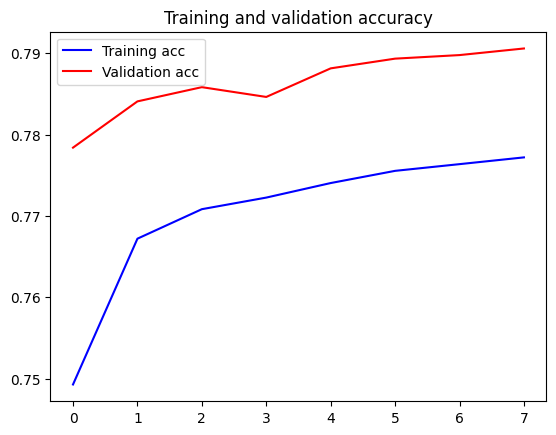

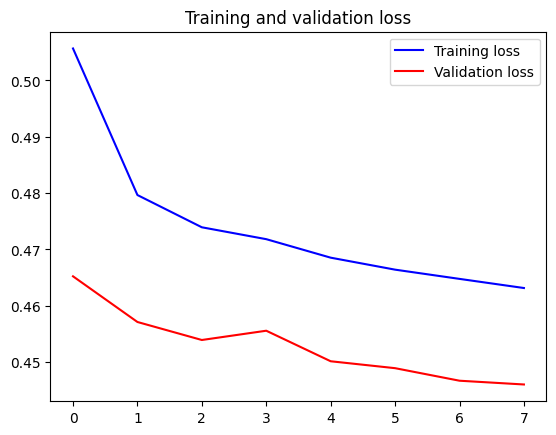

In [74]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
 
epochs = range(len(acc))
 
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
 
plt.figure()
 
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
 
plt.show()

### Predict

In [75]:
def decode_sentiment(score, include_neutral=True):
    if include_neutral:        
        label = NEUTRAL
        if score <= SENTIMENT_THRESHOLDS[0]:
            label = NEGATIVE
        elif score >= SENTIMENT_THRESHOLDS[1]:
            label = POSITIVE

        return label
    else:
        return NEGATIVE if score < 0.5 else POSITIVE

In [78]:
def predict(text, include_neutral=True):
    start_at = time.time()
    # Tokenize text
    x_test = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=SEQUENCE_LENGTH)
    # Predict
    score = float(model.predict([x_test])[0][0])
    # Decode sentiment
    label = decode_sentiment(score, include_neutral=include_neutral)

    return {"label": label, "score": float(score),
       "elapsed_time": time.time()-start_at}  

In [79]:
predict("I love the music")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


{'label': 'POSITIVE',
 'score': 0.9748275876045227,
 'elapsed_time': 0.11768794059753418}

In [80]:
predict("I hate the rain")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


{'label': 'NEGATIVE',
 'score': 0.012681781314313412,
 'elapsed_time': 0.10700702667236328}

In [81]:
predict("i don't know what i'm doing")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


{'label': 'NEGATIVE',
 'score': 0.345455527305603,
 'elapsed_time': 0.15347003936767578}

### Confusion Matrix

In [82]:
%%time
y_pred_1d = []
y_test_1d = list(df_test.target)
scores = model.predict(x_test, verbose=1, batch_size=8000)
y_pred_1d = [decode_sentiment(score, include_neutral=False) for score in scores]

40/40 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step
CPU times: total: 9min 12s
Wall time: 2min 16s


In [83]:
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=30)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90, fontsize=22)
    plt.yticks(tick_marks, classes, fontsize=22)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize=25)
    plt.xlabel('Predicted label', fontsize=25)

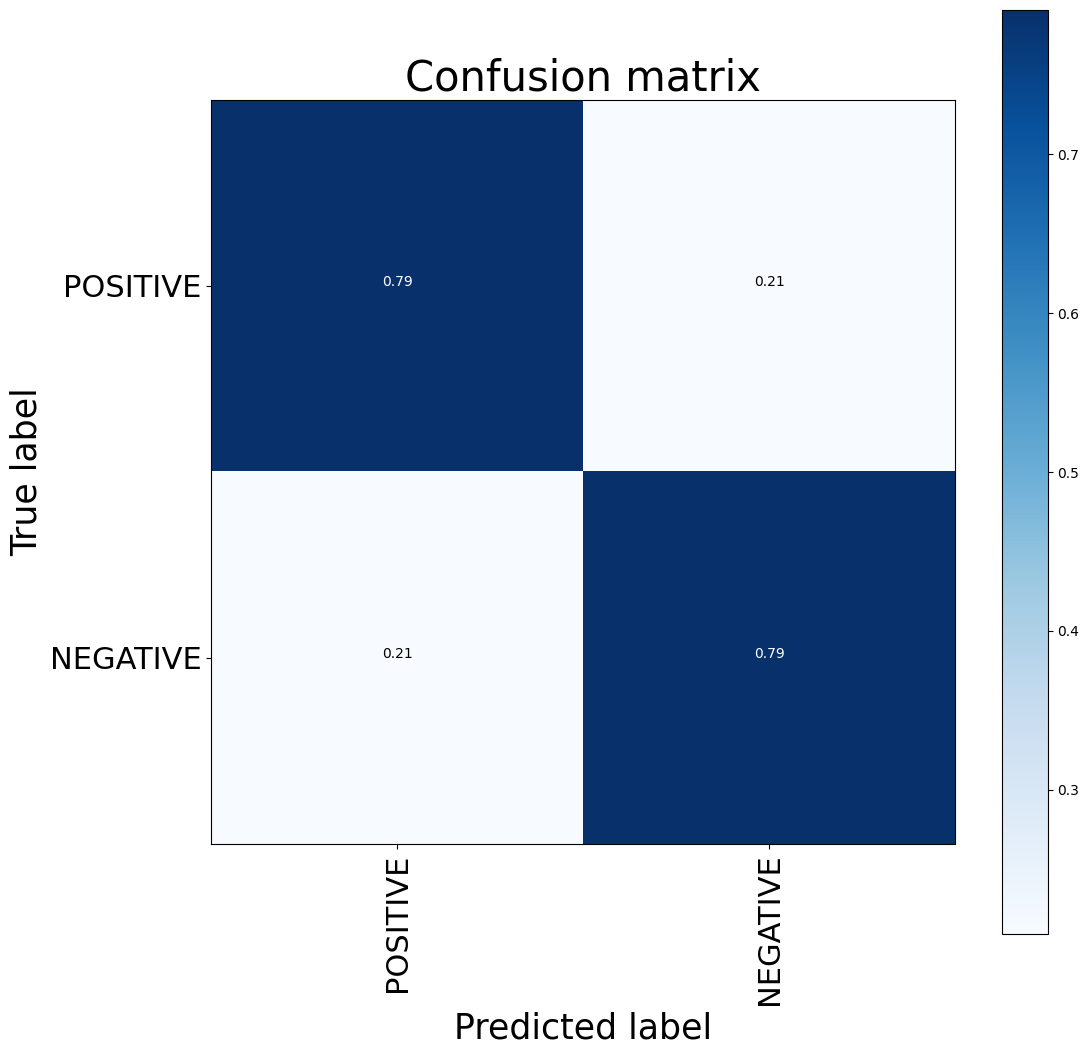

CPU times: total: 312 ms
Wall time: 989 ms


In [84]:
%%time

cnf_matrix = confusion_matrix(y_test_1d, y_pred_1d)
plt.figure(figsize=(12,12))
plot_confusion_matrix(cnf_matrix, classes=df_train.target.unique(), title="Confusion matrix")
plt.show()

### Classification Report

In [85]:
print(classification_report(y_test_1d, y_pred_1d))

              precision    recall  f1-score   support

    NEGATIVE       0.79      0.79      0.79    159494
    POSITIVE       0.79      0.79      0.79    160506

    accuracy                           0.79    320000
   macro avg       0.79      0.79      0.79    320000
weighted avg       0.79      0.79      0.79    320000



### Accuracy Score

In [86]:
accuracy_score(y_test_1d, y_pred_1d)

0.790496875

### Save model